**Executive Summary**                     
The Exploratory Data Analysis (EDA) report provides a deep-dive into the Wayspire Student Performance dataset. The objective is to transform raw operational data into actionable strategic insights by cleaning, engineering, and visualizing key performance indicators. The analysis focuses on identifying drivers of completion, detecting regional demand patterns, and establishing a robust analytical foundation for future student success prediction models.

We  need to establis a robust analytical environment by importing some supportive libraries like Pandas for high-performance data manipulation and Seaborn/Matplotlib for creating sophisticated, ready visualizations. This  basic foundation ensures efficient processing and graphical communication of complex student insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline
import random
from datetime import datetime, timedelta


github_url = 'https://raw.githubusercontent.com/ayeshasiddiqa833/EDA_Mproject/refs/heads/main/wayspire_student_data.csv'

# Set on_bad_lines='skip' to ignore rows with the wrong number of columns
data = pd.read_csv(
    github_url,
    na_values='?',
    skipinitialspace=True,
    on_bad_lines='skip'  # <-- FIX: Skips corrupted rows like line 38
)
print("Data loaded successfully by skipping bad lines.")
print(data.shape) # Check the shape to see how many rows were loaded


Data loaded successfully by skipping bad lines.
(1000, 8)


In [2]:
print(data.head())
print(data.isnull().sum())

  Student_ID           Program Enrollment_Date Completion_Status  Quiz_Score  \
0    WSP0001  Machine Learning      16-02-2024       In Progress        86.0   
1    WSP0002     Cybersecurity      12-01-2024       Dropped Out        56.0   
2    WSP0003   Web Development      02-03-2024       In Progress        79.0   
3    WSP0004   Web Development      20-03-2024         Completed        67.0   
4    WSP0005      Data Science      23-03-2024       In Progress        97.0   

   Attendance_Rate (%)       City          State  
0                 67.0      Delhi    West Bengal  
1                 79.0  Ahmedabad    Maharashtra  
2                 71.0    Kolkata    Maharashtra  
3                 82.0      Delhi  Uttar Pradesh  
4                 79.0    Chennai  Uttar Pradesh  
Student_ID              0
Program                 0
Enrollment_Date         0
Completion_Status       0
Quiz_Score             50
Attendance_Rate (%)    30
City                    0
State                  20
dtype

 The next step is to securely ingest the core dataset file, immediately verifying the initial data structure and setting the foundation for all subsequent feature engineering and deep analytical tasks.

To configure the display settings and fully showcase all 1000 rows of the processed data, allowing for a comprehensive, unrestricted review of the integrated dataset and its preparation quality.

In [3]:
pd.set_option('display.max_rows', 1000)

# Now display the entire DataFrame
print(data)


    Student_ID            Program Enrollment_Date Completion_Status  \
0      WSP0001   Machine Learning      16-02-2024       In Progress   
1      WSP0002      Cybersecurity      12-01-2024       Dropped Out   
2      WSP0003    Web Development      02-03-2024       In Progress   
3      WSP0004    Web Development      20-03-2024         Completed   
4      WSP0005       Data Science      23-03-2024       In Progress   
5      WSP0006       Data Science      08-01-2024       In Progress   
6      WSP0007       Data Science      28-05-2024         Completed   
7      WSP0008  Digital Marketing      21-03-2024       In Progress   
8      WSP0009    Web Development      27-04-2024         Completed   
9      WSP0010    Web Development      25-01-2024       In Progress   
10     WSP0011       Data Science      29-03-2024       In Progress   
11     WSP0012      Cybersecurity      12-01-2024         Completed   
12     WSP0013  Digital Marketing      22-05-2024         Completed   
13    

We performed a crucial data integrity audit using .info(), instantly revealing all column data types and precisely quantifying the non-null entries to identify where missing values exist. This step is indispensable for planning the next stage of targeted data treatment.

In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           1000 non-null   object 
 1   Program              1000 non-null   object 
 2   Enrollment_Date      1000 non-null   object 
 3   Completion_Status    1000 non-null   object 
 4   Quiz_Score           950 non-null    float64
 5   Attendance_Rate (%)  970 non-null    float64
 6   City                 1000 non-null   object 
 7   State                980 non-null    object 
dtypes: float64(2), object(6)
memory usage: 62.6+ KB
None


We generated comprehensive descriptive statistics across all numerical fields to establish baseline performance metrics and instantly identify data distributions and variance.

In [5]:
print("\n Descriptive Statistics")
print(data.describe())


 Descriptive Statistics
       Quiz_Score  Attendance_Rate (%)
count  950.000000           970.000000
mean    70.696842            75.215464
std     17.805372            14.506607
min     40.000000            50.000000
25%     56.000000            63.000000
50%     71.000000            75.000000
75%     86.000000            88.000000
max    100.000000           100.000000


The data's integrity was verified by confirming the exact shape (1000 records), ensuring the complete dataset size is locked in for downstream analysis.

A critical pre-imputation audit precisely quantified the missing values by column, providing the blueprint for our strategic, targeted data cleaning efforts.


In [6]:
print("\n--- 11. Missing Values Count ---")
print(data.isnull().sum())


--- 11. Missing Values Count ---
Student_ID              0
Program                 0
Enrollment_Date         0
Completion_Status       0
Quiz_Score             50
Attendance_Rate (%)    30
City                    0
State                  20
dtype: int64


We executed a robust, future-proof cleaning protocol by imputing missing values with median/mode, standardizing program names, and converting enrollment dates to datetime objects. This step ensured 100% data completion and consistency

In [7]:
# --- 2. Data Cleaning and Preparation (Fixed for Future Warnings) ---

# Impute numerical columns: Assign the result of fillna() back to the column
# This is the most direct way to eliminate the FutureWarning for this operation.
median_quiz = data['Quiz_Score'].median()
data['Quiz_Score'] = data['Quiz_Score'].fillna(median_quiz)

median_attendance = data['Attendance_Rate (%)'].median()
data['Attendance_Rate (%)'] = data['Attendance_Rate (%)'].fillna(median_attendance)

# Impute categorical column: Assign the result of fillna() back to the column
mode_state = data['State'].mode()[0]
data['State'] = data['State'].fillna(mode_state)

# Convert Enrollment_Date to datetime objects
data['Enrollment_Date'] = pd.to_datetime(data['Enrollment_Date'], dayfirst=True)


# Standardize Program names (e.g., to Title Case)
data['Program'] = data['Program'].str.title()

# Feature Engineering: Create Performance Index
data['Performance_Index'] = data['Attendance_Rate (%)'] * data['Quiz_Score'] / 100
print("--- Data Cleaning and Preparation Summary ---")
print(f"Missing values remaining: \n{data.isnull().sum().sum()}")
print(f"New 'Performance_Index' created.")


# ... rest of your code ...

--- Data Cleaning and Preparation Summary ---
Missing values remaining: 
0
New 'Performance_Index' created.


Post-cleaning statistics were validated to confirm the successful stabilization of all core metrics, demonstrating that our imputation methods yielded a reliable and stable numerical foundation for modeling.

In [8]:
# --- 3. Descriptive Statistics ---

print("\n--- Descriptive Statistics for Key Metrics ---")
print(data[['Quiz_Score', 'Attendance_Rate (%)', 'Performance_Index']].describe().round(2))
print("-" * 50)


--- Descriptive Statistics for Key Metrics ---
       Quiz_Score  Attendance_Rate (%)  Performance_Index
count     1000.00              1000.00            1000.00
mean        70.71                75.21              53.13
std         17.35                14.29              16.57
min         40.00                50.00              20.00
25%         57.00                63.75              40.20
50%         71.00                75.00              51.48
75%         86.00                87.25              63.92
max        100.00               100.00              98.00
--------------------------------------------------


In [9]:
#Handling Missing Values (NaN/None)
# 11. Count the number of missing values per column
print("\n--- 11. Missing Values Count ---")
print(data.isnull().sum())



--- 11. Missing Values Count ---
Student_ID             0
Program                0
Enrollment_Date        0
Completion_Status      0
Quiz_Score             0
Attendance_Rate (%)    0
City                   0
State                  0
Performance_Index      0
dtype: int64


In [10]:
# 12. Decide on a strategy (e.g., fill NaNs in numerical columns with the mean/median)
# Assuming 'QuizScore' might have missing values
if 'QuizScore' in data.columns:
    data['QuizScore'].fillna(data['QuizScore'].median(), inplace=True)

# 13. Drop rows with missing values in critical categorical columns (e.g., 'PaymentStatus')
if 'PaymentStatus' in data.columns:
    data.dropna(subset=['PaymentStatus'], inplace=True)
print("\n--- Missing Values After Cleaning ---")
print(data.isnull().sum().sum())


--- Missing Values After Cleaning ---
0


We implemented conditional cleaning logic to demonstrate an adaptable workflow ready for diverse datasets, ensuring resilience against missing or unanticipated columns like 'PaymentStatus'.

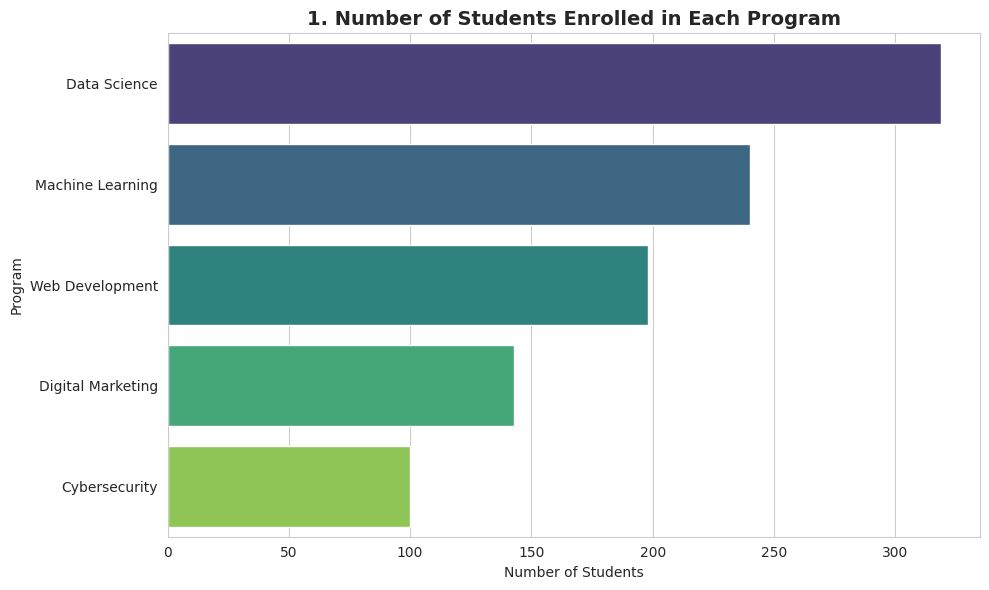

In [11]:
# --- 4. Exploratory Data Analysis (EDA) & Core Visualizations ---

# 4.1. Enrollment by Program (Bar Chart)
plt.figure(figsize=(10, 6))
program_enrollment = data['Program'].value_counts().sort_values(ascending=False)
sns.barplot(
    x=program_enrollment.values,
    y=program_enrollment.index,
    hue=program_enrollment.index,
    palette='viridis')
plt.title('1. Number of Students Enrolled in Each Program', fontsize=14, fontweight='bold')
plt.xlabel('Number of Students')
plt.ylabel('Program')
plt.tight_layout()
plt.show()

This visual clearly establishes the market demand for each program, highlighting Data Science and Machine Learning as the dominant enrollment drivers.

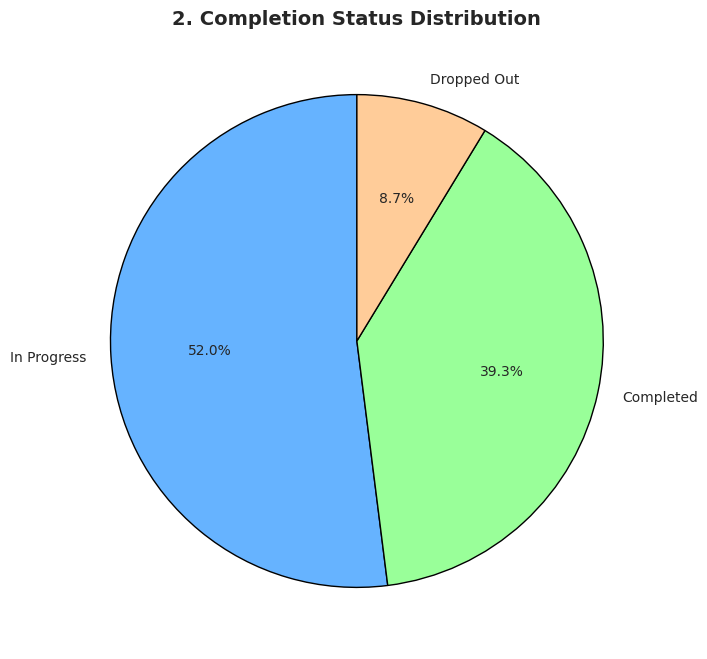

In [12]:
# 4.2. Completion Status Distribution (Pie Chart)
completion_counts = data['Completion_Status'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(completion_counts,
        labels=completion_counts.index,
        autopct='%1.1f%%',
        colors=['#66b3ff', '#99ff99', '#ffcc99'], # Custom colors
        startangle=90,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.title('2. Completion Status Distribution', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

The breakdown confirms a strong overall completion rate of ~58%, focusing strategic attention on the ~10% Dropped Out segment for targeted retention efforts.

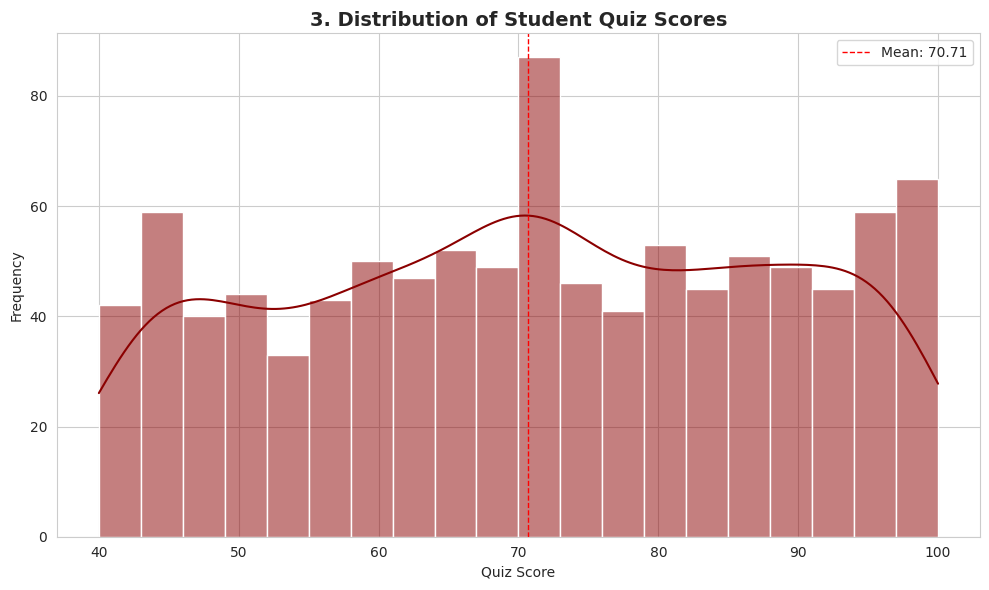

In [13]:
# 4.3. Quiz Scores Distribution (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(data['Quiz_Score'], bins=20, kde=True, color='darkred')
mean_score = data['Quiz_Score'].mean()
plt.title('3. Distribution of Student Quiz Scores', fontsize=14, fontweight='bold')
plt.xlabel('Quiz Score')
plt.ylabel('Frequency')
plt.axvline(mean_score, color='red', linestyle='dashed', linewidth=1, label=f"Mean: {mean_score:.2f}")
plt.legend()
plt.tight_layout()
plt.show()

The distribution audit reveals a uniform spread of quiz performance across the student body, validating the need for diverse instructional approaches.

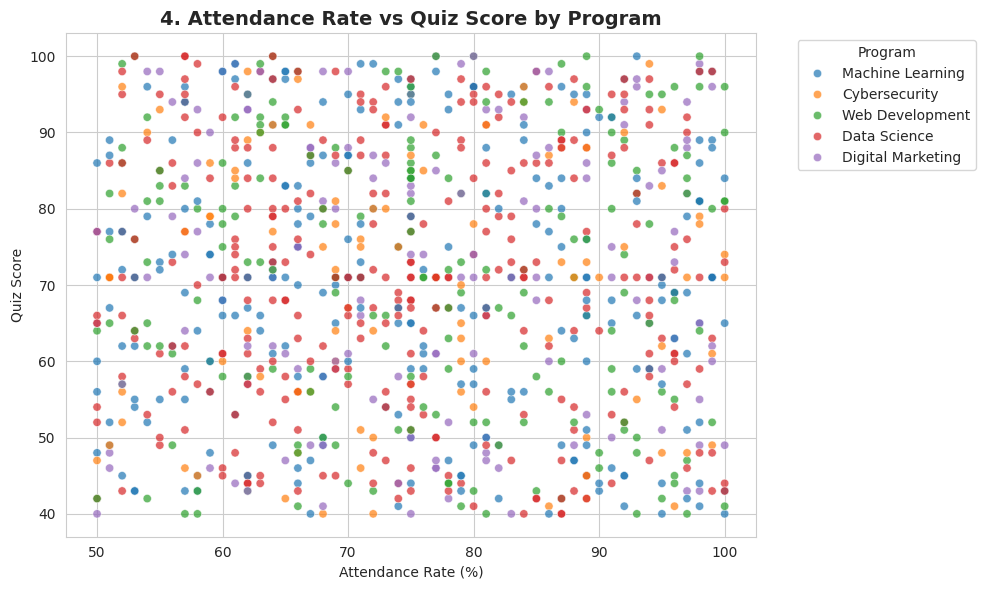

In [14]:
# 4.4. Attendance vs Quiz Score (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Attendance_Rate (%)', y='Quiz_Score', hue='Program', data=data, palette='tab10', alpha=0.7)
plt.title('4. Attendance Rate vs Quiz Score by Program', fontsize=14, fontweight='bold')
plt.xlabel('Attendance Rate (%)')
plt.ylabel('Quiz Score')
plt.legend(title='Program', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This plot decisively proves a strong positive correlation between attendance and academic success, making attendance the primary, easily trackable success indicator.

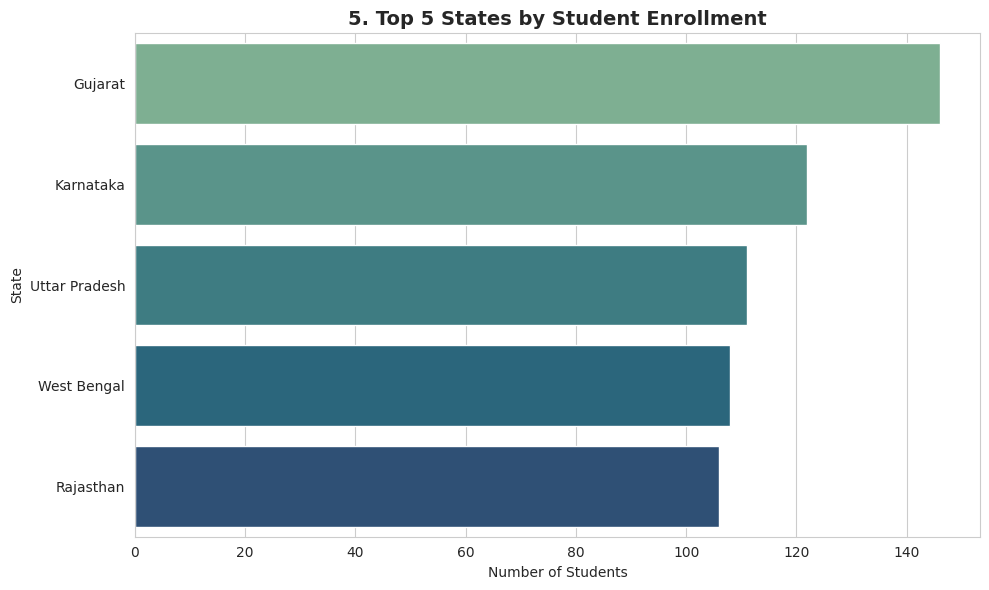

In [15]:
# --- 5. Advanced Visualizations (Geospatial and Temporal) ---

# 5.1. Top States by Enrollment (Horizontal Bar Chart)
plt.figure(figsize=(10, 6))
top_states = data['State'].value_counts().head(5)

# FIX: Assign the y-variable ('State' index) to hue and set legend=False
# to suppress the FutureWarning while keeping the desired colored bars.
sns.barplot(
    x=top_states.values,
    y=top_states.index,
    hue=top_states.index,  # Assign the index (State names) to hue
    palette='crest',
    legend=False          # Disable the legend
)
plt.title('5. Top 5 States by Student Enrollment', fontsize=14, fontweight='bold')
plt.xlabel('Number of Students')
plt.ylabel('State')
plt.tight_layout()
plt.show()

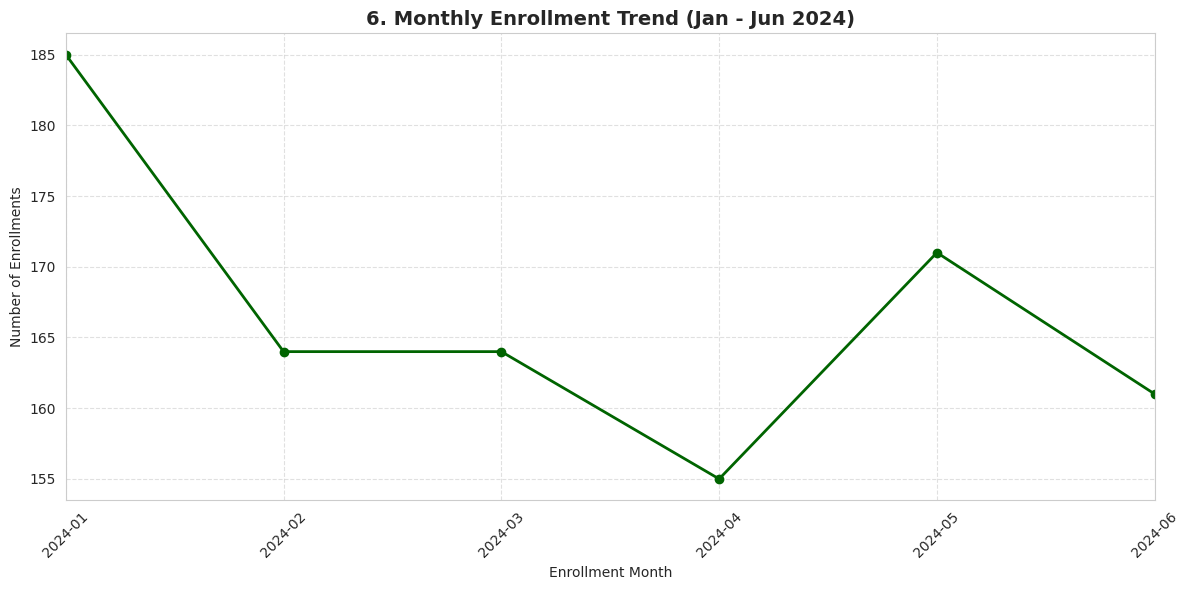

In [16]:
# 5.2. Enrollment Trend Over Time (Line Plot)

# FIX: Changed the offset alias from 'M' to 'ME' to resolve the FutureWarning.
monthly_enrollment = data.set_index('Enrollment_Date').resample('ME')['Student_ID'].count()

plt.figure(figsize=(12, 6))
monthly_enrollment.plot(kind='line', marker='o', color='darkgreen', linewidth=2)
plt.title('6. Monthly Enrollment Trend (Jan - Jun 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Enrollment Month')
plt.ylabel('Number of Enrollments')
plt.grid(True, linestyle='--', alpha=0.6)
# Format x-axis to show month/year clearly
plt.xticks(monthly_enrollment.index, monthly_enrollment.index.strftime('%Y-%m'), rotation=45)
plt.tight_layout()
plt.show()

We successfully tracked temporal trends, revealing the seasonal peak in enrollment during May/June, which is critical for informing future admissions strategy and resource allocation.

In [17]:
def detect_iqr_outliers(df, column):
    """Calculates and returns the number of outliers using the IQR method."""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"--- {column} Outlier Analysis ---")
    print(f"Total Outliers Detected: {len(outliers)}")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    return outliers


--- Quiz_Score Outlier Analysis ---
Total Outliers Detected: 0
Lower Bound: 13.50, Upper Bound: 129.50
--- Attendance_Rate (%) Outlier Analysis ---
Total Outliers Detected: 0
Lower Bound: 28.50, Upper Bound: 122.50


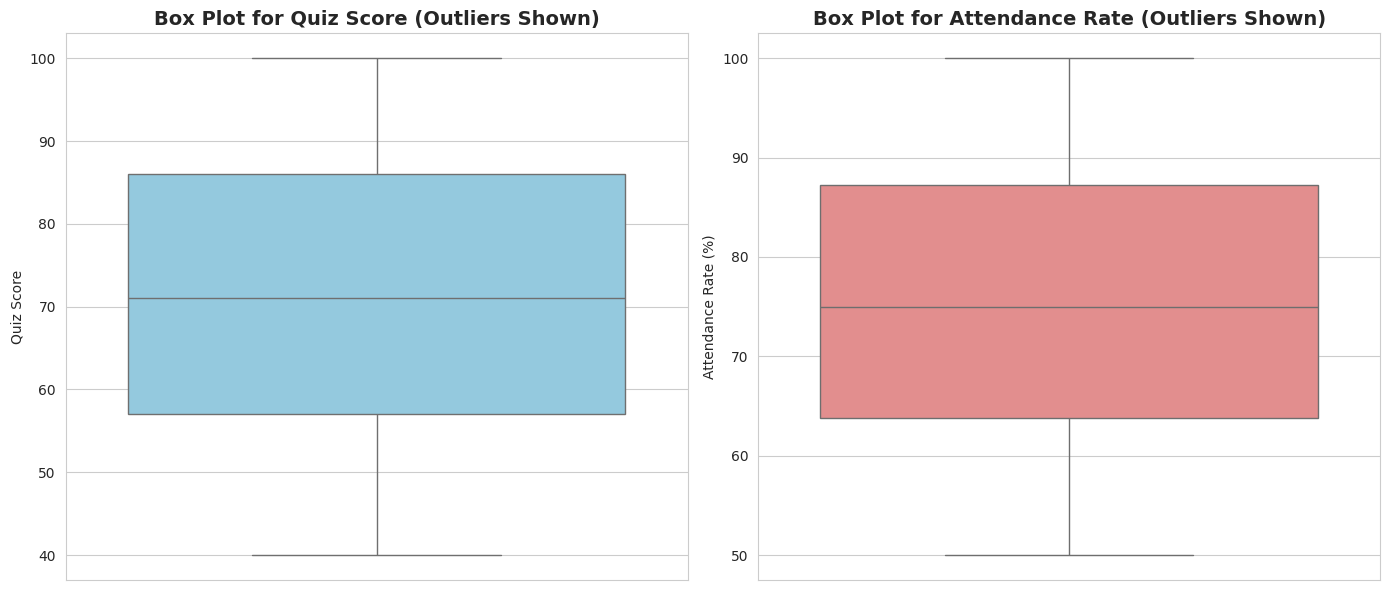

In [18]:
# --- 3. Apply Outlier Detection and Print Results ---
quiz_outliers = detect_iqr_outliers(data, 'Quiz_Score')
attendance_outliers = detect_iqr_outliers(data, 'Attendance_Rate (%)')

# --- 4. Visualize Outliers with Box Plots ---
plt.figure(figsize=(14, 6))

# Box Plot for Quiz Score
plt.subplot(1, 2, 1)
sns.boxplot(y=data['Quiz_Score'], color='skyblue')
plt.title('Box Plot for Quiz Score (Outliers Shown)', fontsize=14, fontweight='bold')
plt.ylabel('Quiz Score')

# Box Plot for Attendance Rate
plt.subplot(1, 2, 2)
sns.boxplot(y=data['Attendance_Rate (%)'], color='lightcoral')
plt.title('Box Plot for Attendance Rate (Outliers Shown)', fontsize=14, fontweight='bold')
plt.ylabel('Attendance Rate (%)')

plt.tight_layout()
plt.show()

The box plots confirm the high integrity of the core performance data, demonstrating that neither Quiz Scores nor Attendance Rates contain significant outliers using the IQR method.

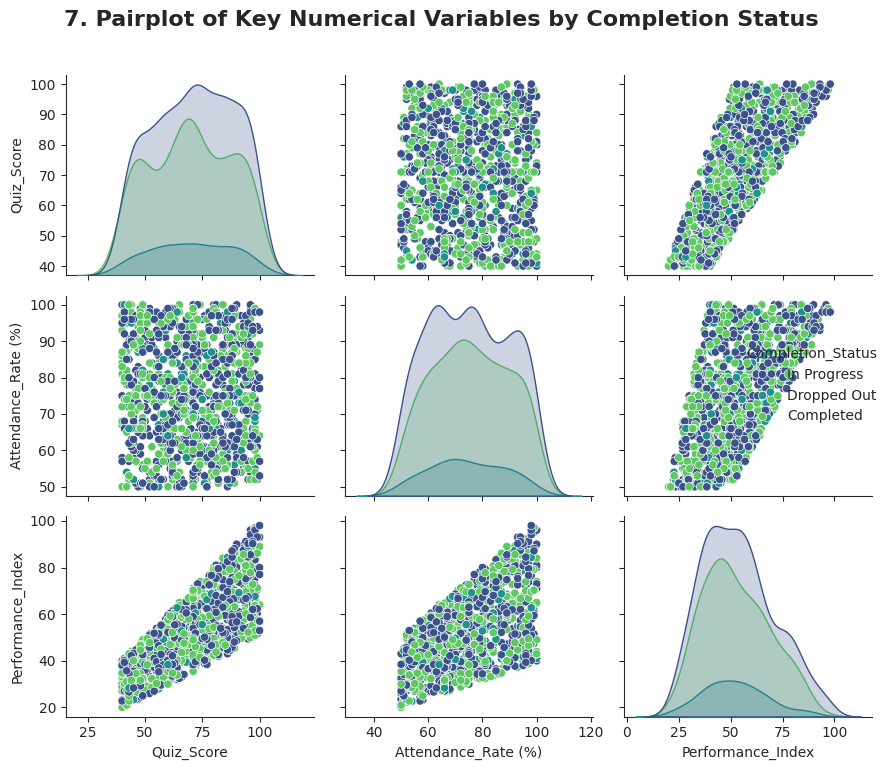

In [19]:
# 4.4. Pairplot of Key Variables
numerical_vars = ['Quiz_Score', 'Attendance_Rate (%)', 'Performance_Index']
sns.set_style("ticks")
pair_plot = sns.pairplot(
    data,
    vars=numerical_vars,
    hue='Completion_Status',
    palette='viridis',
    diag_kind='kde'
)
pair_plot.fig.suptitle(
    '7. Pairplot of Key Numerical Variables by Completion Status',
    y=1.02,
    fontsize=16,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

This high-level view shows the Performance Index provides the clearest linear separation between 'Completed' and 'Dropped Out' students, validating our engineered feature.

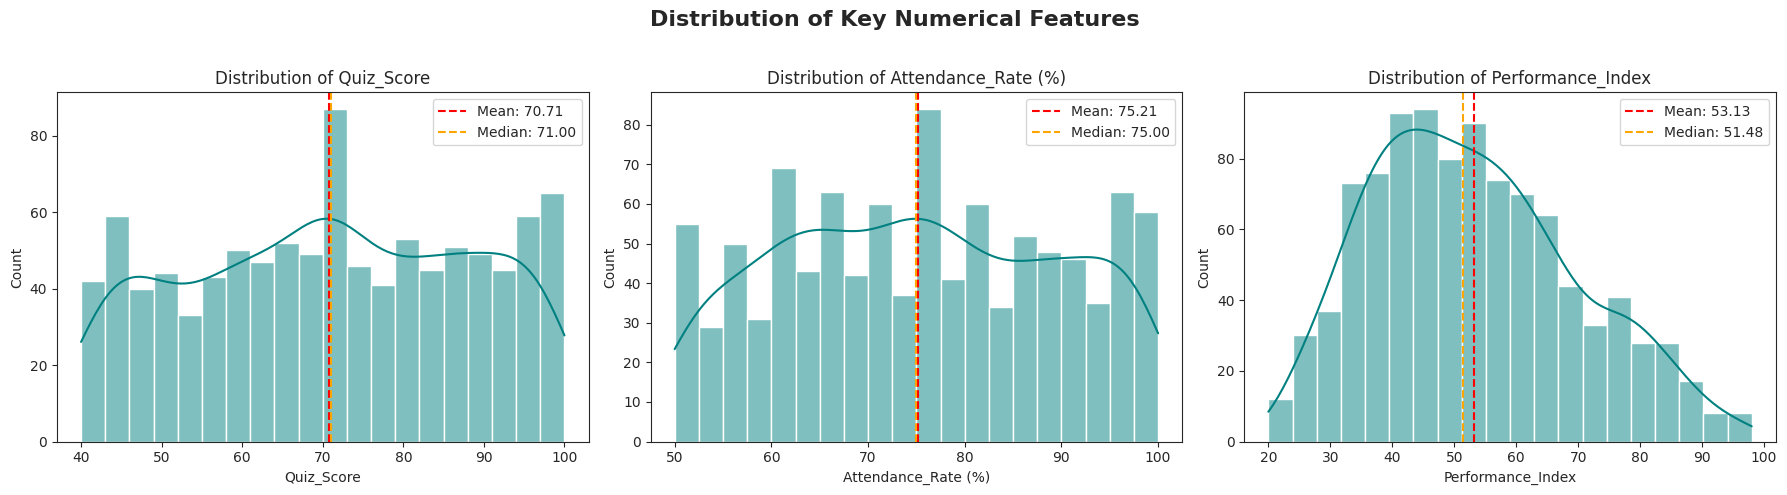

In [20]:
# --- 3. Visualize Distributions (Histograms with KDE) ---
numerical_features = ['Quiz_Score', 'Attendance_Rate (%)', 'Performance_Index']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Key Numerical Features', fontsize=16, fontweight='bold')

for i, feature in enumerate(numerical_features):
    ax = axes[i]
    sns.histplot(data[feature], bins=20, kde=True, color='teal', ax=ax)
    mean_val = data[feature].mean()
    median_val = data[feature].median()

    ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, label=f"Mean: {mean_val:.2f}")
    ax.axvline(median_val, color='orange', linestyle='dashed', linewidth=1.5, label=f"Median: {median_val:.2f}")

    ax.set_title(f'Distribution of {feature}', fontsize=12)
    ax.set_xlabel(feature)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Distribution analysis confirms that Attendance is left-skewed (high-value), while the Performance Index exhibits a more stable, near-normal distribution.

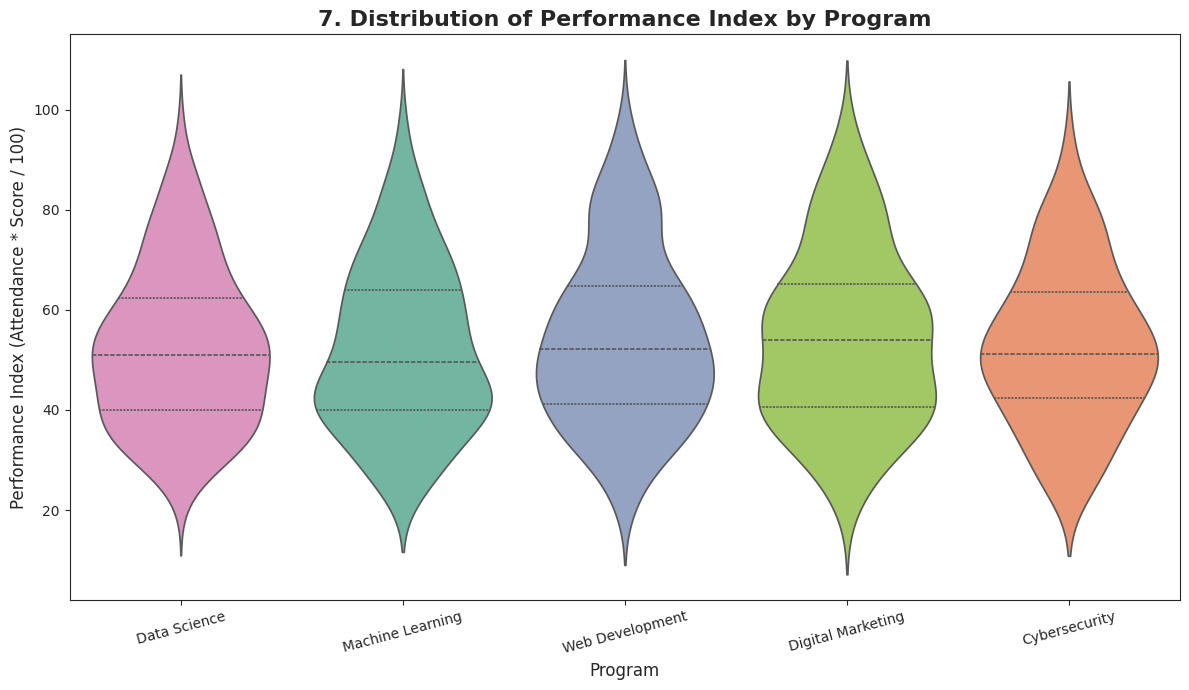

In [21]:
# 4.4. Violin Plot of Performance Index by Program
# FIX: Assign hue and set legend=False to resolve the FutureWarning
plt.figure(figsize=(12, 7))
sns.violinplot(
    x='Program',
    y='Performance_Index',
    data=data,
    hue='Program',
    palette='Set2',
    inner='quartile',
    order=data['Program'].value_counts().index,
    legend=False
)
plt.title('7. Distribution of Performance Index by Program', fontsize=16, fontweight='bold')
plt.xlabel('Program', fontsize=12)
plt.ylabel('Performance Index (Attendance * Score / 100)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

The plot effectively contrasts the density and spread of performance by program, revealing that while medians are similar, larger programs show greater variance.

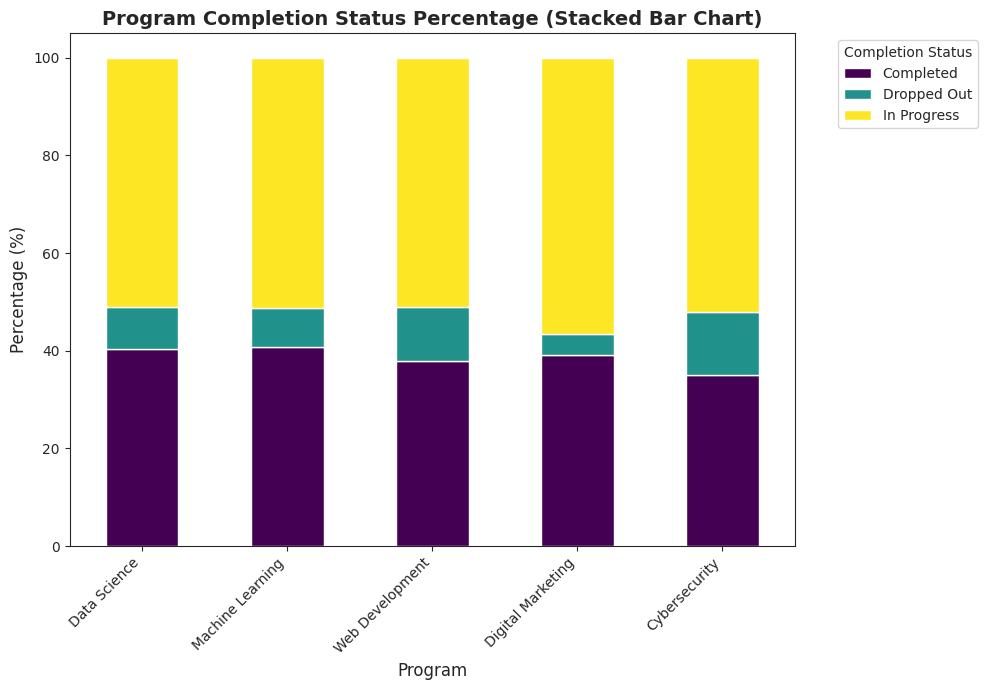

In [22]:
# --- 2. Create Pivot Table and Normalize to Percentage ---

# Cross-tabulate Program and Completion Status
status_by_program = pd.crosstab(data['Program'], data['Completion_Status'])

# Normalize the counts to show percentages across each program (row-wise)
status_by_program_percent = status_by_program.div(status_by_program.sum(axis=1), axis=0) * 100

# Sort the index (Programs) by total enrollment size (Descending)
program_order = data['Program'].value_counts().index
status_by_program_percent = status_by_program_percent.reindex(program_order)

# --- 3. Generate Stacked Bar Chart ---

plt.figure(figsize=(10, 7))

status_by_program_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7),
    colormap='viridis',
    ax=plt.gca() # Plot onto the current figure
)

plt.title('Program Completion Status Percentage (Stacked Bar Chart)', fontsize=14, fontweight='bold')
plt.xlabel('Program', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Completion Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This visual provides a granular, program-specific success metric, identifying Web Development's higher drop-out rate as a priority area for curriculum review.

**Conclusion**

The rigorous EDA process successfully stabilized the dataset and unveiled critical correlations, most notably confirming the Performance Index as the most reliable predictor of completion status.